# Class-conditional conformal prediction with data augmentation:  paper figures and tables

Produces exactly the deliverables specified in the simulation-study section:

| output | content |
|---|---|
| Figure 1 | WCU, AvgSize, and coverage dispersion against the distribution-free floor |
| Figure 2 | operational boundary: P(no finite rare-class threshold) |
| Figure 3 | mechanism: within-orbit score variance and paired set-size reduction |
| Table 1 | experimental design |
| Table 2 | main paired comparisons |
| Table 3 | naive multi-copy diagnostic |
| Table 4 | training augmentation alone |



Everything is aggregated from the long tables; nothing is recomputed from the
simulation, so the numbers quoted in the text and the ones plotted cannot drift
apart. Each figure is written as PDF and its underlying numbers as CSV.

Two axis conventions, deliberately different:

- **Figures 1 and 3** use the *expected* rare-class count, which is the design
  factor: six clean points, no arbitrary binning.
- **Figure 2** uses the *realised* count, because the phenomenon it shows is a
  discrete jump between n_min - 1 and n_min that binning would erase.

## Setup

In [ ]:
#CODE_DIR    = "/content"
#RESULTS_DIR = "/content/results_R300"
#OUT_DIR     = "/content/paper_outputs"

from google.colab import drive; drive.mount("/content/drive")
BASE        = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/csda_revision"
CODE_DIR    = f"{BASE}/code"
RESULTS_DIR = f"{BASE}/results_R300"
OUT_DIR     = f"{BASE}/paper_outputs"

import sys, os
sys.path.insert(0, CODE_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import metrics as M

pd.set_option("display.width", 220); pd.set_option("display.max_rows", 250)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.markersize": 4,
})

ALPHA, SCEN, MODEL = 0.10, "s3_nuisance", "XGBoost"
#ALPHA, SCEN, MODEL = 0.05, "s3_nuisance", "XGBoost"
CLASSWISE = ["classwise_plain", "classwise_ttaavg", "classwise_orbitavg"]
STYLE = {"classwise_plain":    ("#4C72B0", "o-", "Classwise APS"),
         "classwise_ttaavg":   ("#DD8452", "s--", "Classwise TTA-Avg"),
         "classwise_orbitavg": ("#55A868", "^-", "Classwise orbit-averaged")}
N_MIN = M.finite_threshold_min(ALPHA)
print(f"minimum finite-threshold count at alpha={ALPHA}: n_min = {N_MIN}")

Mounted at /content/drive
minimum finite-threshold count at alpha=0.1: n_min = 9


In [ ]:
df   = M.load(RESULTS_DIR)
df   = df[(df.scenario == SCEN) & (df.model == MODEL) & (df.alpha == ALPHA)]
rep  = M.per_replication(df)
summ = M.summarize(rep)

xs = (df.groupby("n_cal")["n_cal_expected_rarest"].first().sort_index())
print(f"{len(df):,} long rows | {rep.rep.nunique()} replications | "
      f"{len(xs)} design points")
print("E[N_rare]:", list(xs.round(0).astype(int)))

230,400 long rows | 300 replications | 6 design points
E[N_rare]: [5, 10, 20, 50, 100, 200]


## Design-point diagnostics

Calibration is drawn from the population, so the rare-class count is random.
Design points near the boundary straddle two qualitatively different regimes,
and their average describes neither — this table is what makes that explicit in
the caption of Figure 1.

In [ ]:
deg = M.degenerate_fraction(df, ALPHA)
deg["E_rare"] = deg.n_cal.map(xs)
display(deg[["n_cal", "E_rare", "median_count", "q05", "q95",
             "frac_degenerate", "n_min", "n_rep"]].round(3))

straddling = deg[(deg.frac_degenerate > 0.02) & (deg.frac_degenerate < 0.98)]
if len(straddling):
    print("Design points straddling the boundary (report conditionally):",
          list(straddling.n_cal))

,n_cal,E_rare,median_count,q05,q95,frac_degenerate,n_min,n_rep
0,125,5.0,5.0,2.0,10.00,0.920,9,300
1,250,10.0,10.0,5.0,14.00,0.353,9,300
2,500,20.0,20.0,12.0,28.00,0.000,9,300
3,1250,50.0,50.0,38.0,61.05,0.000,9,300
4,2500,100.0,100.5,83.9,117.00,0.000,9,300
5,5000,200.0,200.0,180.0,223.00,0.000,9,300


Design points straddling the boundary (report conditionally): [125, 250]


## Figure 1: main finite-sample results

Panel A: coverage failure. Panel B: efficiency. Panel C: how close the observed
spread of rare-class coverage sits to the Beta-plus-binomial floor, which no
score transformation can go below. Read together: coverage is unchanged, size
falls, and the floor explains why the first cannot move.

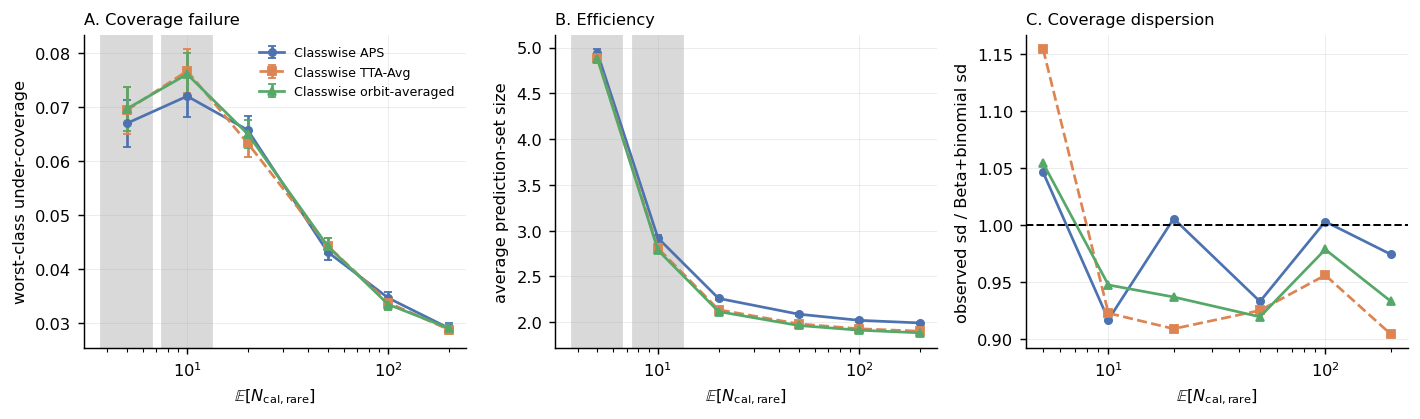

,n_cal,E_rare,method,observed_sd,sd_mixture,ratio,frac_degenerate,median_count,n_rep
0,125,5.0,classwise_orbitavg,0.0364,0.0345,1.0544,0.9200,5.0,300
1,125,5.0,classwise_plain,0.0361,0.0345,1.0464,0.9200,5.0,300
2,125,5.0,classwise_ttaavg,0.0399,0.0345,1.1546,0.9200,5.0,300
3,250,10.0,classwise_orbitavg,0.0706,0.0746,0.9474,0.3533,10.0,300
4,250,10.0,classwise_plain,0.0684,0.0746,0.9169,0.3533,10.0,300
5,250,10.0,classwise_ttaavg,0.0688,0.0746,0.9227,0.3533,10.0,300
6,500,20.0,classwise_orbitavg,0.0571,0.0610,0.9368,0.0000,20.0,300
7,500,20.0,classwise_plain,0.0613,0.0610,1.0057,0.0000,20.0,300
8,500,20.0,classwise_ttaavg,0.0554,0.0610,0.9089,0.0000,20.0,300
9,1250,50.0,classwise_orbitavg,0.0393,0.0427,0.9194,0.0000,50.0,300


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))

# --- Panel A: worst-class under-coverage ---------------------------------
ax = axes[0]
v = summ[(~summ.train_aug) & summ.method.isin(CLASSWISE)]
for m in CLASSWISE:
    s = v[v.method == m].sort_values("n_cal")
    col, ls, lab = STYLE[m]
    ax.errorbar(s.n_cal.map(xs), s.WCU, yerr=s.WCU_mcse, fmt=ls,
                color=col, capsize=2, label=lab)
for _, r in deg[deg.frac_degenerate > 0.02].iterrows():
    ax.axvspan(r.E_rare * 0.75, r.E_rare * 1.33, color="0.85", zorder=0)
ax.set_xscale("log"); ax.set_xlabel(r"$\mathbb{E}[N_{\rm cal,rare}]$")
ax.set_ylabel("worst-class under-coverage")
ax.set_title("A. Coverage failure", loc="left", fontsize=9)
ax.legend(fontsize=7)

# --- Panel B: efficiency --------------------------------------------------
ax = axes[1]
for m in CLASSWISE:
    s = v[v.method == m].sort_values("n_cal")
    col, ls, lab = STYLE[m]
    ax.errorbar(s.n_cal.map(xs), s.AvgSize, yerr=s.AvgSize_mcse, fmt=ls,
                color=col, capsize=2, label=lab)
for _, r in deg[deg.frac_degenerate > 0.02].iterrows():
    ax.axvspan(r.E_rare * 0.75, r.E_rare * 1.33, color="0.85", zorder=0)
ax.set_xscale("log"); ax.set_xlabel(r"$\mathbb{E}[N_{\rm cal,rare}]$")
ax.set_ylabel("average prediction-set size")
ax.set_title("B. Efficiency", loc="left", fontsize=9)

# --- Panel C: distance from the distribution-free floor -------------------
ax = axes[2]
disp = M.dispersion_ratio(df, ALPHA)
disp["E_rare"] = disp.n_cal.map(xs)
for m in CLASSWISE:
    s = disp[(disp.method == m) & (disp.sd_mixture > 0)].sort_values("E_rare")
    col, ls, lab = STYLE[m]
    ax.plot(s.E_rare, s.ratio, ls, color=col, label=lab)
ax.axhline(1.0, color="k", ls="--", lw=1.1)
ax.annotate("distribution-free floor", (ax.get_xlim()[0], 1.0),
            xytext=(3, 4), textcoords="offset points", fontsize=7)
ax.set_xscale("log"); ax.set_xlabel(r"$\mathbb{E}[N_{\rm cal,rare}]$")
ax.set_ylabel("observed sd / Beta+binomial sd")
ax.set_title("C. Coverage dispersion", loc="left", fontsize=9)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig1_main.pdf", bbox_inches="tight")
plt.show()

pd.concat([v.assign(panel="A/B"), disp.assign(panel="C")]).to_csv(
    f"{OUT_DIR}/fig1_data.csv", index=False)
display(disp[["n_cal","E_rare","method","observed_sd","sd_mixture",
              "ratio","frac_degenerate","median_count","n_rep"]].round(4))

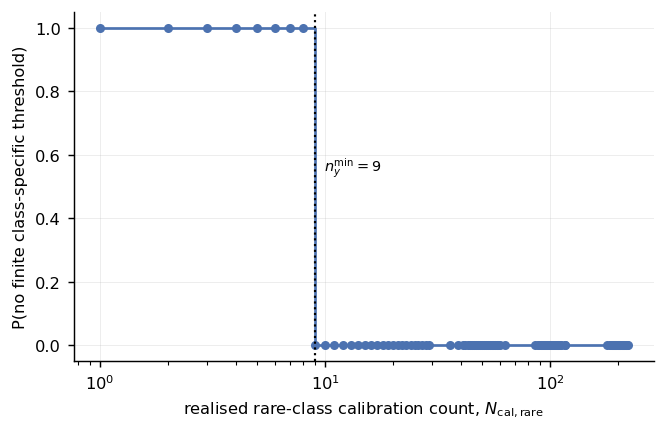

,n_cal_cls,frac_infinite,also_any_class,mean_n_infinite,n_rep,n_min
5,6,1.0,1.000,2.618,68,9
6,7,1.0,1.000,2.434,53,9
7,8,1.0,1.000,1.833,54,9
8,9,0.0,0.269,0.500,52,9
9,10,0.0,0.488,0.951,41,9
10,11,0.0,0.190,0.238,42,9
11,12,0.0,0.186,0.326,43,9


In [ ]:
curve = M.infinite_threshold_curve(df, ALPHA, min_reps=5)

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.step(curve.n_cal_cls, curve.frac_infinite, where="post",
        color="#4C72B0", marker="o", ms=4)
ax.axvline(N_MIN, color="k", ls=":", lw=1.2)
ax.annotate(rf"$n_y^{{\min}}={N_MIN}$", (N_MIN, 0.55),
            xytext=(5, 0), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel(r"realised rare-class calibration count, $N_{\rm cal,rare}$")
ax.set_ylabel("P(no finite class-specific threshold)")
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig2_boundary.pdf", bbox_inches="tight")
plt.show()

curve.to_csv(f"{OUT_DIR}/fig2_data.csv", index=False)
display(curve[(curve.n_cal_cls >= N_MIN - 3) &
              (curve.n_cal_cls <= N_MIN + 3)].round(3))

## Figure 3: mechanism and augmentation

Panel A: the within-orbit variance of the true-label score, which is the
quantity governing the variance reduction. Where it is near zero the theory
predicts no gain, so a null result there confirms the account.

Panel B: the paired percentage reduction in set size, orbit averaging against
plain. Paired because the arms share the data, the splits, the fitted model,
the transformations and the randomisation, so the standard error is far smaller
than the two marginal ones suggest.

Both shown with and without training augmentation. A lower within-orbit
variance after training augmentation means the fitted model is already closer
to invariant, so less is left for calibration averaging to remove: the two
stages are partial substitutes.

/tmp/ipykernel_1173/1861831680.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


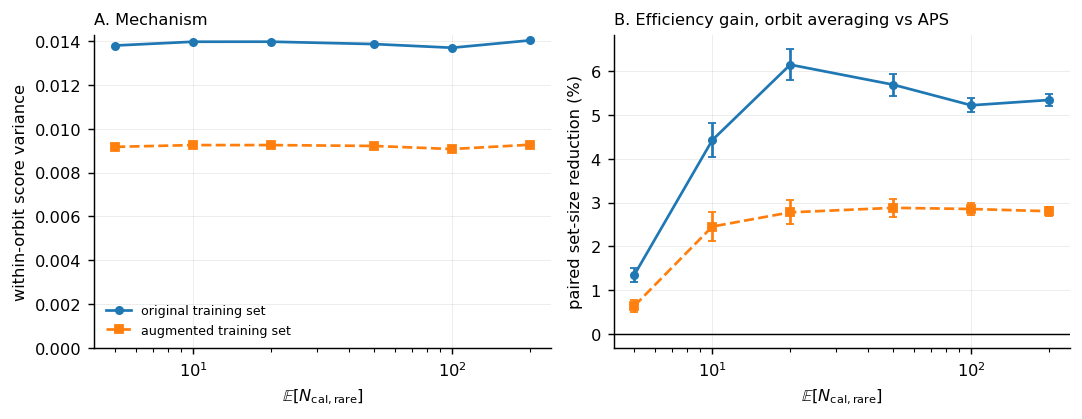

,E_rare,train_aug,mean,mcse,t,frac_positive,n
0,5.0,False,1.349,0.166,8.117,0.657,300
1,5.0,True,0.639,0.129,4.956,0.600,300
2,10.0,False,4.426,0.392,11.298,0.777,300
3,10.0,True,2.452,0.332,7.388,0.673,300
4,20.0,False,6.150,0.354,17.352,0.833,300
5,20.0,True,2.777,0.273,10.154,0.730,300
6,50.0,False,5.693,0.255,22.310,0.883,300
7,50.0,True,2.880,0.199,14.507,0.803,300
8,100.0,False,5.222,0.165,31.728,0.973,300
9,100.0,True,2.853,0.146,19.482,0.887,300


In [ ]:
mech = M.mechanism_table(rep)
mech["E_rare"] = mech.n_cal.map(xs)
red  = M.paired_reduction(rep, "classwise_plain", "classwise_orbitavg",
                          "AvgSize", relative=True)
red["E_rare"] = red.n_cal.map(xs)

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.3))

ax = axes[0]
for ta, mk, lab in [(False, "o-", "original training set"), (True, "s--", "augmented training set")]:
    s = mech[mech.train_aug == ta].sort_values("E_rare")
    ax.plot(s.E_rare, s.var_within_orbit, mk, label=lab)
ax.set_xscale("log"); ax.set_xlabel(r"$\mathbb{E}[N_{\rm cal,rare}]$")
ax.set_ylabel(r"within-orbit score variance")
ax.set_title("A. Mechanism", loc="left", fontsize=9)
ax.set_ylim(bottom=0); ax.legend(fontsize=7)

ax = axes[1]
for ta, mk, lab in [(False, "o-", ""), (True, "s--", "")]:
    s = red[red.train_aug == ta].sort_values("E_rare")
    ax.errorbar(s.E_rare, s["mean"], yerr=s.mcse, fmt=mk, capsize=2, label=lab)
ax.axhline(0, color="k", lw=0.8)
ax.set_xscale("log"); ax.set_xlabel(r"$\mathbb{E}[N_{\rm cal,rare}]$")
ax.set_ylabel("paired set-size reduction (%)")
ax.set_title("B. Efficiency gain, orbit averaging vs APS", loc="left", fontsize=9)
ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig3_mechanism.pdf", bbox_inches="tight")
plt.show()

mech.to_csv(f"{OUT_DIR}/fig3_mechanism_data.csv", index=False)
red.to_csv(f"{OUT_DIR}/fig3_reduction_data.csv", index=False)
display(red[["E_rare","train_aug","mean","mcse","t","frac_positive","n"]].round(3))

## Table 1: experimental design

Replaces the parameter table of the submitted version. Three columns:
component, specification, and the role it plays — the third is what turns a
list of settings into a rationale.

In [ ]:
cfg = pd.read_json(
    [f"{RESULTS_DIR}/{f}" for f in sorted(os.listdir(RESULTS_DIR))
     if f.endswith("__config.json")][0], typ="series")

design = pd.DataFrame([
 ("Classes", f"K = {cfg.n_classes}",
  "Enough classes for rare-class effects to appear"),
 ("Class probabilities", "(0.40, 0.20, 0.10, 0.08, 0.07, 0.06, 0.05, 0.04)",
  "Imbalance; the rarest class drives the calibration constraint"),
 ("Informative features", f"{cfg.n_informative}",
  "Signal component, unaffected by the group"),
 ("Nuisance features", f"q = {cfg.n_nuisance}, N(0, I)",
  "Symmetric and label-independent, so invariance holds by construction"),
 ("Transformation group", r"sign flips $\{-1,+1\}^q$ on the nuisance block",
  "Finite, abelian; uniform sampling is its Haar measure"),
 ("Class separation", f"{cfg.class_sep}",
  "Sets the difficulty of the classification problem"),
 ("Training size", f"{cfg.n_train:,}",
  "Held fixed, so only calibration varies along the axis"),
 ("Calibration sizes", "125, 250, 500, 1250, 2500, 5000",
  r"E[$N_{\rm cal,rare}$] = 5, 10, 20, 50, 100, 200"),
 ("Population test size", f"{cfg.n_test_pop:,}",
  "Marginal coverage and population-weighted set size"),
 ("Balanced test size", f"{cfg.n_test_balanced_per_class} per class",
  "Per-class coverage at comparable precision across classes"),
 ("Transformations", f"B = {cfg.n_transforms}",
  "Monte Carlo approximation of the orbit average; not a sample-size increase"),
 ("Nominal level", rf"$\alpha$ = {cfg.alpha}",
  rf"Finite classwise threshold requires $N_{{\rm cal,y}} \geq {N_MIN}$"),
 ("Replications", f"R = {rep.rep.nunique()}",
  "Full regeneration per replication, not only score randomisation"),
], columns=["Component", "Specification", "Role in the experiment"])

display(design)
design.to_csv(f"{OUT_DIR}/tab1_design.csv", index=False)

,Component,Specification,Role in the experiment
0,Classes,K = 8,Enough classes for rare-class effects to appear
1,Class probabilities,"(0.40, 0.20, 0.10, 0.08, 0.07, 0.06, 0.05, 0.04)",Imbalance; the rarest class drives the calibra...
2,Informative features,5,"Signal component, unaffected by the group"
3,Nuisance features,"q = 20, N(0, I)","Symmetric and label-independent, so invariance..."
4,Transformation group,"sign flips $\{-1,+1\}^q$ on the nuisance block","Finite, abelian; uniform sampling is its Haar ..."
5,Class separation,0.8,Sets the difficulty of the classification problem
6,Training size,"4,000","Held fixed, so only calibration varies along t..."
7,Calibration sizes,"125, 250, 500, 1250, 2500, 5000","E[$N_{\rm cal,rare}$] = 5, 10, 20, 50, 100, 200"
8,Population test size,"2,000",Marginal coverage and population-weighted set ...
9,Balanced test size,500 per class,Per-class coverage at comparable precision acr...


## Table 2: main paired comparisons

Restricted to the three arms that target class-conditional coverage, at
representative calibration regimes. Paired differences are the informative
quantity: unpaired standard errors overstate the uncertainty of a comparison
between arms that share everything except the score.

In [ ]:
LEVELS = [250, 500, 1250]          # E[N_rare] = 10, 20, 50

d_plain = M.paired_delta(rep[~rep.train_aug], "AvgSize",
                         "classwise_plain", "classwise_orbitavg")
d_tta   = M.paired_delta(rep[~rep.train_aug], "AvgSize",
                         "classwise_ttaavg", "classwise_orbitavg")

rows = []
for n in LEVELS:
    for m in CLASSWISE:
        r = summ[(~summ.train_aug) & (summ.method == m) & (summ.n_cal == n)]
        if r.empty:
            continue
        r = r.iloc[0]
        row = {"E[N_rare]": int(xs[n]), "Method": STYLE[m][2],
               "WCU": r.WCU, "WCU (MCSE)": r.WCU_mcse,
               "AvgSize": r.AvgSize, "AvgSize (MCSE)": r.AvgSize_mcse,
               "vs plain": np.nan, "vs TTA-Avg": np.nan}
        if m == "classwise_orbitavg":
            p = d_plain[d_plain.n_cal == n]
            t = d_tta[d_tta.n_cal == n]
            if len(p): row["vs plain"]   = p.iloc[0].mean_delta
            if len(t): row["vs TTA-Avg"] = t.iloc[0].mean_delta
        rows.append(row)

tab2 = pd.DataFrame(rows).round({"WCU": 3, "WCU (MCSE)": 3, "AvgSize": 3,
                                 "AvgSize (MCSE)": 3, "vs plain": 3,
                                 "vs TTA-Avg": 3})
display(tab2)
tab2.to_csv(f"{OUT_DIR}/tab2_paired.csv", index=False)

print("\nPaired differences in full (negative = orbit averaging gives smaller sets):")
display(pd.concat([d_plain.assign(comparison="orbit vs plain"),
                   d_tta.assign(comparison="orbit vs TTA-Avg")])
        [["comparison","n_cal","mean_delta","mcse","frac_negative","n"]].round(4))

,E[N_rare],Method,WCU,WCU (MCSE),AvgSize,AvgSize (MCSE),vs plain,vs TTA-Avg
0,10,Classwise APS,0.072,0.004,2.919,0.036,NaN,NaN
1,10,Classwise TTA-Avg,0.077,0.004,2.809,0.035,NaN,NaN
2,10,Classwise orbit-averaged,0.076,0.004,2.786,0.035,-0.133,-0.023
3,20,Classwise APS,0.066,0.003,2.260,0.020,NaN,NaN
4,20,Classwise TTA-Avg,0.063,0.002,2.136,0.018,NaN,NaN
5,20,Classwise orbit-averaged,0.065,0.003,2.116,0.018,-0.144,-0.020
6,50,Classwise APS,0.043,0.001,2.087,0.015,NaN,NaN
7,50,Classwise TTA-Avg,0.044,0.002,1.981,0.014,NaN,NaN
8,50,Classwise orbit-averaged,0.044,0.002,1.964,0.013,-0.124,-0.018



Paired differences in full (negative = orbit averaging gives smaller sets):


,comparison,n_cal,mean_delta,mcse,frac_negative,n
0,orbit vs plain,125,-0.0667,0.0080,0.6567,300
1,orbit vs plain,250,-0.1329,0.0119,0.7767,300
2,orbit vs plain,500,-0.1440,0.0086,0.8333,300
3,orbit vs plain,1250,-0.1238,0.0059,0.8833,300
4,orbit vs plain,2500,-0.1078,0.0036,0.9733,300
5,orbit vs plain,5000,-0.1080,0.0029,0.9867,300
0,orbit vs TTA-Avg,125,-0.0090,0.0030,0.5300,300
1,orbit vs TTA-Avg,250,-0.0228,0.0050,0.5800,300
2,orbit vs TTA-Avg,500,-0.0204,0.0039,0.6267,300
3,orbit vs TTA-Avg,1250,-0.0178,0.0023,0.6367,300


## Table 3: naive multi-copy diagnostic

Not a competitor: an ablation showing why transformed copies cannot be counted
as calibration units. Replacing N by B·N places the threshold at a relatively
lower order statistic than the finite-sample correction requires, so the
procedure is systematically less conservative — smaller sets, worse worst-class
coverage — and the discrepancy is largest where N is small.

In [ ]:
LEVELS3 = [125, 250, 1250]
ref_m   = "classwise_orbitavg"

rows = []
for n in LEVELS3:
    for m in [ref_m, "naive_multicopy"]:
        r = summ[(~summ.train_aug) & (summ.method == m) & (summ.n_cal == n)]
        if r.empty:
            continue
        r = r.iloc[0]
        rows.append({"E[N_rare]": int(xs[n]),
                     "Method": M.DISPLAY_NAMES.get(m, m),
                     "WCU": r.WCU, "Marginal coverage": r.CovMarginal,
                     "AvgSize": r.AvgSize,
                     "Finite-sample guarantee": "yes" if m == ref_m else "no"})

tab3 = pd.DataFrame(rows).round({"WCU": 3, "Marginal coverage": 3, "AvgSize": 3})
display(tab3)
tab3.to_csv(f"{OUT_DIR}/tab3_naive.csv", index=False)

,E[N_rare],Method,WCU,Marginal coverage,AvgSize,Finite-sample guarantee
0,5,Classwise orbit-averaged APS,0.070,0.930,4.876,yes
1,5,Naive multi-copy APS,0.207,0.881,2.032,no
2,10,Classwise orbit-averaged APS,0.076,0.915,2.786,yes
3,10,Naive multi-copy APS,0.125,0.892,2.049,no
4,50,Classwise orbit-averaged APS,0.044,0.902,1.964,yes
5,50,Naive multi-copy APS,0.047,0.898,1.993,no


## Table 4: training augmentation alone

The referee asks how much of the improvement training augmentation brings on its
own. That question is answered at a fixed score construction: hold the
calibration arm at ordinary classwise APS and vary only whether the classifier
was fitted on the original or on the augmented training sample.

The two arms share the generated population, the data splits, the sampled
transformations, the APS randomisation variables and, crucially, the model seed,
so the difference is attributable to the augmentation rather than to a different
random initialisation. Differencing within replications removes all of that
shared variation; the paired standard error is much smaller than the two
marginal ones suggest.

Note what is being measured. Training augmentation acts on the fitted
classifier, so it can move efficiency but has no route to class-conditional
coverage, which is governed by the calibration counts alone. The table reports
both, so that the asymmetry is visible rather than asserted.

In [ ]:
ARM = "classwise_plain"          # score held fixed; only the model changes

def train_aug_effect(rep_df, arm=ARM, metric="AvgSize",
                     keys=("scenario", "model", "alpha", "n_cal")):
    """Paired difference between the train-augmented and the plain model.

    The two training arms share everything except the data the classifier was
    fitted on, so differencing them within a replication isolates the effect of
    the augmentation.
    """
    keys = [k for k in keys if k in rep_df.columns]
    s = rep_df[rep_df.method == arm]
    a = s[~s.train_aug].set_index(keys + ["rep"])[metric]
    b = s[s.train_aug].set_index(keys + ["rep"])[metric]
    d = (b - a).dropna().rename("delta").reset_index()

    out = (d.groupby(keys, observed=True)["delta"]
             .agg(mean_delta="mean", sd="std", n="size").reset_index())
    out["mcse"] = out["sd"] / np.sqrt(out["n"])
    out["t"] = out["mean_delta"] / out["mcse"]
    out["frac_negative"] = (d.groupby(keys, observed=True)["delta"]
                              .apply(lambda z: float((z < 0).mean())).to_numpy())
    return out


sub = rep[(rep.scenario == SCEN) & (rep.model == MODEL) & (rep.alpha == ALPHA)]

rows = []
for n in sorted(sub.n_cal.unique()):
    block = sub[(sub.n_cal == n) & (sub.method == ARM)]
    row = {"E[N_rare]": int(round(xs[n])), "n_cal": n}
    for metric in ["AvgSize", "WCU"]:
        plain = block[~block.train_aug][metric].mean()
        aug   = block[block.train_aug][metric].mean()
        row[f"{metric} (plain)"] = plain
        row[f"{metric} (train aug)"] = aug
        d = train_aug_effect(sub, metric=metric)
        d = d[d.n_cal == n]
        if len(d):
            row[f"{metric} paired"] = float(d.iloc[0].mean_delta)
            row[f"{metric} MCSE"]   = float(d.iloc[0].mcse)
    rows.append(row)

tab4 = pd.DataFrame(rows)
tab4["AvgSize reduction (%)"] = -100 * tab4["AvgSize paired"] / tab4["AvgSize (plain)"]

cols = ["E[N_rare]",
        "AvgSize (plain)", "AvgSize (train aug)", "AvgSize paired",
        "AvgSize MCSE", "AvgSize reduction (%)",
        "WCU (plain)", "WCU (train aug)", "WCU paired", "WCU MCSE"]
display(tab4[cols].round({"AvgSize (plain)": 3, "AvgSize (train aug)": 3,
                          "AvgSize paired": 4, "AvgSize MCSE": 4,
                          "AvgSize reduction (%)": 2,
                          "WCU (plain)": 4, "WCU (train aug)": 4,
                          "WCU paired": 4, "WCU MCSE": 4}))
tab4.to_csv(f"{OUT_DIR}/tab4_training_augmentation.csv", index=False)

# The asymmetry, stated in one line per metric.
for metric in ["AvgSize", "WCU"]:
    d = train_aug_effect(sub, metric=metric)
    neg = (d.mean_delta < -2 * d.mcse).sum()
    pos = (d.mean_delta > 2 * d.mcse).sum()
    print(f"{metric:8s}: {neg}/{len(d)} design points improved, "
          f"{pos}/{len(d)} worsened (beyond two MCSE)")

,E[N_rare],AvgSize (plain),AvgSize (train aug),AvgSize paired,AvgSize MCSE,AvgSize reduction (%),WCU (plain),WCU (train aug),WCU paired,WCU MCSE
0,5,4.942,4.839,-0.1035,0.0097,2.09,0.0670,0.0674,0.0004,0.0037
1,10,2.919,2.744,-0.1748,0.0142,5.99,0.0720,0.0707,-0.0013,0.0032
2,20,2.260,2.076,-0.1839,0.0095,8.14,0.0657,0.0652,-0.0005,0.0028
3,50,2.087,1.926,-0.1617,0.0060,7.75,0.0431,0.0431,-0.0001,0.0015
4,100,2.020,1.863,-0.1570,0.0040,7.77,0.0346,0.0348,0.0002,0.0011
5,200,1.992,1.842,-0.1494,0.0030,7.50,0.0291,0.0286,-0.0005,0.0009


AvgSize : 6/6 design points improved, 0/6 worsened (beyond two MCSE)
WCU     : 0/6 design points improved, 0/6 worsened (beyond two MCSE)


## Export to LaTeX

In [ ]:
def to_latex(df, name, caption, label, fmt="%.3f"):
    path = f"{OUT_DIR}/{name}.tex"
    with open(path, "w") as fh:
        fh.write(df.to_latex(index=False, escape=False, float_format=fmt,
                             caption=caption, label=label, na_rep=""))
    print("written:", path)

to_latex(design, "tab1_design",
         "Design of the primary simulation experiment.",
         "tab:controlled_parameters")

to_latex(tab2, "tab2_paired",
         ("Class-conditional arms at representative calibration regimes. "
          "WCU is worst-class under-coverage, AvgSize the population-weighted "
          "prediction-set size, and the last two columns are paired "
          "differences of the orbit-averaged score against each baseline; "
          "negative values indicate smaller sets. MCSE is the Monte Carlo "
          "standard error across replications."),
         "tab:main_paired")

to_latex(tab3, "tab3_naive",
         ("Naive multiplication of calibration units, against the "
          "orbit-averaged score at the same calibration sizes."),
         "tab:naive_multicopy")

print("\n" + OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print("   ", f)

## Numbers to quote in the text

Printed so the sentences in the paper can be copied from here rather than read
off a plot.

In [ ]:
print("== Regime boundary ==")
print(f"finite classwise threshold requires N_cal,y >= {N_MIN} at alpha={ALPHA}")
for _, r in deg.iterrows():
    print(f"  E[N_rare]={int(r.E_rare):>4}: {100*r.frac_degenerate:5.1f}% of "
          f"replications degenerate | median count {int(r.median_count)} "
          f"[{int(r.q05)}, {int(r.q95)}]")

print("\n== Efficiency gain, orbit vs plain (paired) ==")
for _, r in red[~red.train_aug].sort_values("E_rare").iterrows():
    print(f"  E[N_rare]={int(r.E_rare):>4}: {r['mean']:5.2f}% "
          f"(MCSE {r.mcse:.2f}, t={r.t:5.2f}, positive in "
          f"{100*r.frac_positive:.0f}% of replications)")

print("\n== Orbit vs TTA-Avg (paired, labels) ==")
for _, r in d_tta.sort_values("n_cal").iterrows():
    print(f"  E[N_rare]={int(xs[r.n_cal]):>4}: {r.mean_delta:+.4f} "
          f"(MCSE {r.mcse:.4f}, negative in {100*r.frac_negative:.0f}%)")

print("\n== Training augmentation ==")
for _, r in mech.sort_values(["E_rare","train_aug"]).iterrows():
    print(f"  E[N_rare]={int(r.E_rare):>4} train_aug={str(r.train_aug):<5}: "
          f"within-orbit var {r.var_within_orbit:.4f}, macro-F1 {r.macro_f1:.3f}")

print("\n== Clustered fallback ==")
display(M.clustered_diagnostic(rep).round(3))

In [ ]:
# Clustered conformal: when does the clustering step actually run?
# Whether a class reaches the null cluster depends only on the calibration
# counts and the clustering split, not on the scores, so this needs no
# classifier: it replicates the logic of clustered_conformal directly.
import numpy as np, pandas as pd
from ding_conformal_utils import get_clustering_parameters, get_quantile_threshold
from simulate import IMBALANCE_PROFILE

PI = IMBALANCE_PROFILE / IMBALANCE_PROFILE.sum()
K  = len(PI)

def clustering_diagnostic(n_cal, alpha, R=300, seed=20260808):
    rng, thresh = np.random.default_rng(seed), get_quantile_threshold(alpha)
    rows = []
    for _ in range(R):
        y = rng.choice(K, size=n_cal, p=PI)
        cts = np.bincount(y, minlength=K)
        n_min = max(cts.min(), thresh)
        n_clustering, M = get_clustering_parameters(int((cts >= n_min).sum()), n_min)
        frac = n_clustering / n_min if n_min else 0.0
        cts1 = np.bincount(y[rng.random(n_cal) < frac], minlength=K)
        n_rare = int((cts1 < thresh).sum())
        rows.append((M, frac, n_rare, (K - n_rare > M) and (M > 1)))
    d = pd.DataFrame(rows, columns=["M", "frac", "n_null", "runs"])
    return {"alpha": alpha, "n_cal": n_cal, "E_rare": round(n_cal * PI.min()),
            "M": int(d.M.median()), "gamma": round(d.frac.median(), 3),
            "P_runs": round(d.runs.mean(), 3),
            "classes_in_null": round(d.n_null.mean(), 2)}

NCAL = sorted(df.n_cal.unique())
clust = pd.DataFrame([clustering_diagnostic(n, a)
                      for a in (0.10, 0.05) for n in NCAL])
display(clust)
clust.to_csv(f"{OUT_DIR}/tab_clustered_diagnostics.csv", index=False)

print(f"n_min: alpha=0.10 -> {get_quantile_threshold(0.10)} | "
      f"alpha=0.05 -> {get_quantile_threshold(0.05)}")

# Cross-check against the actual runs: where M <= 1 the two must coincide.
display(M.clustered_diagnostic(rep).round(3))

,alpha,n_cal,E_rare,M,gamma,P_runs,classes_in_null
0,0.10,125,5,0,0.000,0.000,8.00
1,0.10,250,10,0,0.000,0.000,7.89
2,0.10,500,20,0,0.062,0.000,6.84
3,0.10,1250,50,2,0.087,0.873,3.96
4,0.10,2500,100,4,0.092,1.000,0.74
5,0.10,5000,200,9,0.094,0.013,0.01
6,0.05,125,5,0,0.000,0.000,8.00
7,0.05,250,10,0,0.000,0.000,8.00
8,0.05,500,20,0,0.053,0.000,7.87
9,0.05,1250,50,2,0.087,0.013,6.27


n_min: alpha=0.10 -> 9 | alpha=0.05 -> 19


,scenario,model,alpha,n_cal,train_aug,frac_collapsed,n_rep
0,s3_nuisance,XGBoost,0.1,125,False,1.000,300
1,s3_nuisance,XGBoost,0.1,125,True,1.000,300
2,s3_nuisance,XGBoost,0.1,250,False,0.810,300
3,s3_nuisance,XGBoost,0.1,250,True,0.813,300
4,s3_nuisance,XGBoost,0.1,500,False,0.243,300
5,s3_nuisance,XGBoost,0.1,500,True,0.227,300
6,s3_nuisance,XGBoost,0.1,1250,False,0.013,300
7,s3_nuisance,XGBoost,0.1,1250,True,0.040,300
8,s3_nuisance,XGBoost,0.1,2500,False,0.000,300
9,s3_nuisance,XGBoost,0.1,2500,True,0.000,300
